In [ ]:
# # Introduction
# # Financial loan services are leveraged by companies across many industries, from big banks to financial institutions to government loans.
# One of the primary objectives of companies with financial loan services is to decrease payment defaults and ensure that individuals are 
# paying back their loans as expected. In order to do this efficiently and systematically, many companies employ machine learning to predict 
# which individuals are at the highest risk of defaulting on their loans, so that proper interventions can be effectively deployed to the right audience.

# # Description
# # This dataset has been taken from Coursera's Loan Default Prediction Challenge and will provide you the opportunity to tackle 
#     one of the most industry-relevant machine learning problems with a unique dataset that will put your modeling skills to the test. 
# The dataset contains 255,347 rows and 18 columns in total.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline
#plt.style.use('dark_background')


In [2]:
import os
os.environ["PYPANDOC_PANDOC"] = r"C:\Program Files\Pandoc\pandoc.exe"



In [3]:
df = pd.read_csv("Loan_default.csv")

In [4]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [5]:
# statistics
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [6]:
# Missing data
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [7]:
# status value count
df['Default'].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

In [8]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64

In [9]:
df['Education'].value_counts()

Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64

In [10]:
df['LoanPurpose'].value_counts()

LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64

In [11]:
df['HasCoSigner'].value_counts()

HasCoSigner
Yes    127701
No     127646
Name: count, dtype: int64

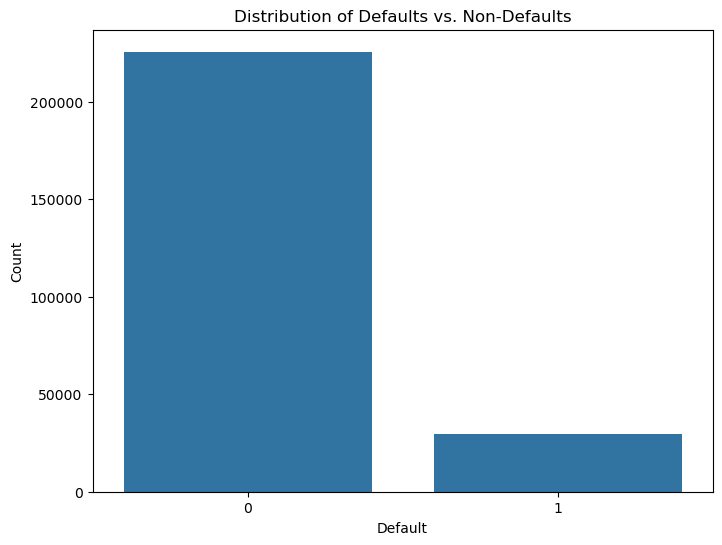

In [12]:
# Distribution of Defaults vs. Non-Defaults
plt.figure(figsize=(8, 6))
sns.countplot(x='Default', data=df)
plt.title('Distribution of Defaults vs. Non-Defaults')
plt.xlabel('Default')
plt.ylabel('Count')
plt.show()

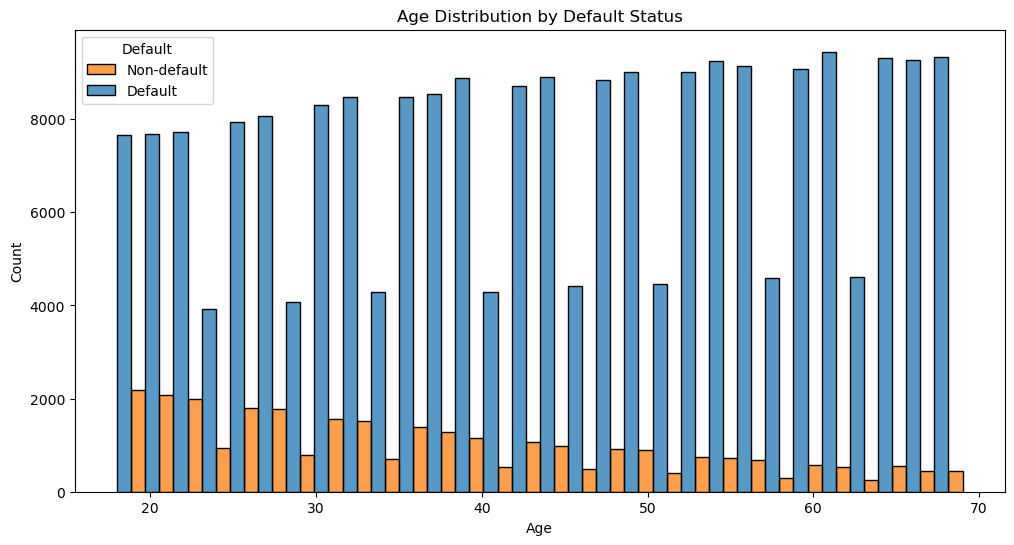

In [13]:
# Side-by-side Bar Plot for Age Distribution by Default Status
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Age', hue='Default', multiple="dodge", bins=30)
plt.title('Age Distribution by Default Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Default', labels=['Non-default', 'Default'])
plt.show()

C:\Users\sumit\AppData\Local\Temp\ipykernel_13996\4225918883.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Default', y='CreditScore', data=df, palette='Set1')


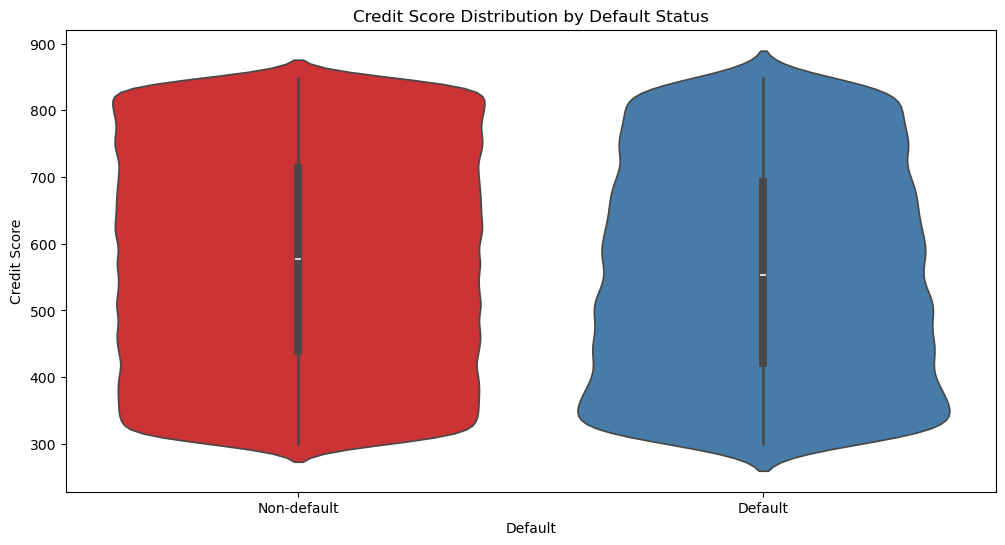

In [14]:
# Violin Plot for Credit Score by Default Status
plt.figure(figsize=(12, 6))
sns.violinplot(x='Default', y='CreditScore', data=df, palette='Set1')
plt.title('Credit Score Distribution by Default Status')
plt.xlabel('Default')
plt.ylabel('Credit Score')
plt.xticks([0, 1], ['Non-default', 'Default'])
plt.show()

OBSERVATION ( remember two alter the comment)
Median: The white dot in each plot represents the median credit score. By comparing the position of these dots, you can get an idea of whether the median credit score is higher for individuals who have defaulted or those who have not.
Interquartile Range: The thick black bar in the center of each plot represents the interquartile range, which contains the middle 50% of the credit scores. If one plot’s interquartile range is higher than the other’s, it means that the middle 50% of credit scores are generally higher for that group
Distribution Shape: The overall shape of the violin plot gives you an idea of how the credit scores are distributed. A wider section indicates a higher frequency of individuals with credit scores in that range. By comparing the shapes, you can see if there are significant differences in the distribution of credit scores between the two group
. Outliers: If there are any points outside the main body of the violin plot, these represent outliers or scores that are significantly higher or lower than the rest. Comparing the outliers can provide insights into the range of credit scores in each group.

In [97]:
!pip install shap

   ---------------------------------------- 0.0/547.8 kB ? eta -:--:--
   ---------------------------------------- 547.8/547.8 kB 2.5 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [slicer]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [99]:
!pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
    --------------------------------------- 1.0/72.0 MB 5.8 MB/s eta 0:00:13
    --------------------------------------- 1.3/72.0 MB 3.8 MB/s eta 0:00:19
   - -------------------------------------- 2.4/72.0 MB 4.6 MB/s eta 0:00:16
   - -------------------------------------- 3.4/72.0 MB 4.4 MB/s eta 0:00:16
   -- ------------------------------------- 4.5/72.0 MB 4.3 MB/s eta 0:00:16
   -- ------------------------------------- 5.2/72.0 MB 4.2 MB/s eta 0:00:16
   --- ------------------------------------ 6.0/72.0 MB 4.1 MB/s eta 0:00:16
   --- ------------------------------------ 6.8/72.0 MB 4.1 MB/s eta 0:00:16
   ---- ----------------------------------- 7.6/72.0 MB 4.1 MB/s eta 0:00:16
   ---- ----------------------------------- 8.4/72.0 MB 4.1 MB/s eta 0:00:16
   ----- ---------------------------------- 9.2/72.0 MB 4.0 MB/s eta 0:00:16
   ----- ---------------------------------- 10.0/72.0 MB 4.0 MB/s eta 0:00:16
   --

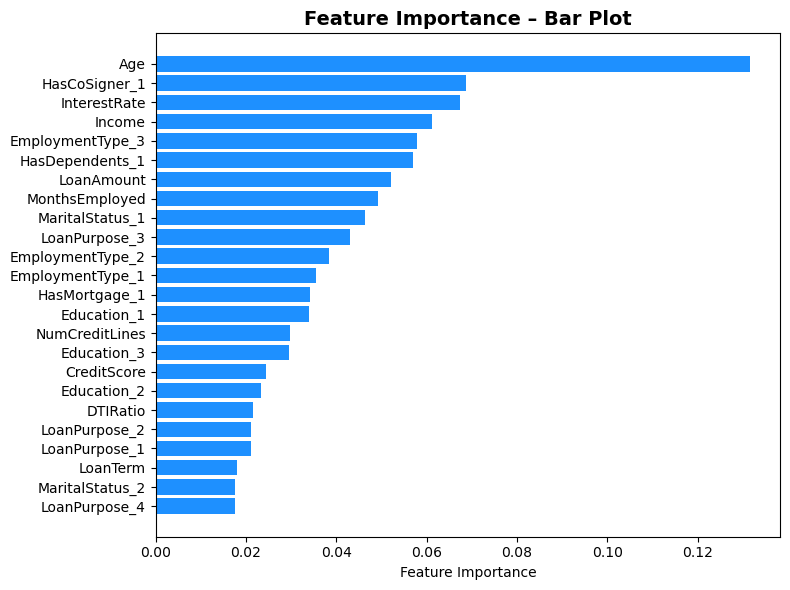

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# Assuming df is your dataframe and target column is 'Default'
X = df.drop(columns=['Default'])
y = df['Default']

# Train model
model = XGBClassifier(random_state=42)
model.fit(X, y)

# Get feature importances directly from model
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='dodgerblue')
plt.xlabel('Feature Importance')
plt.title('Feature Importance – Bar Plot', fontsize=14, weight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


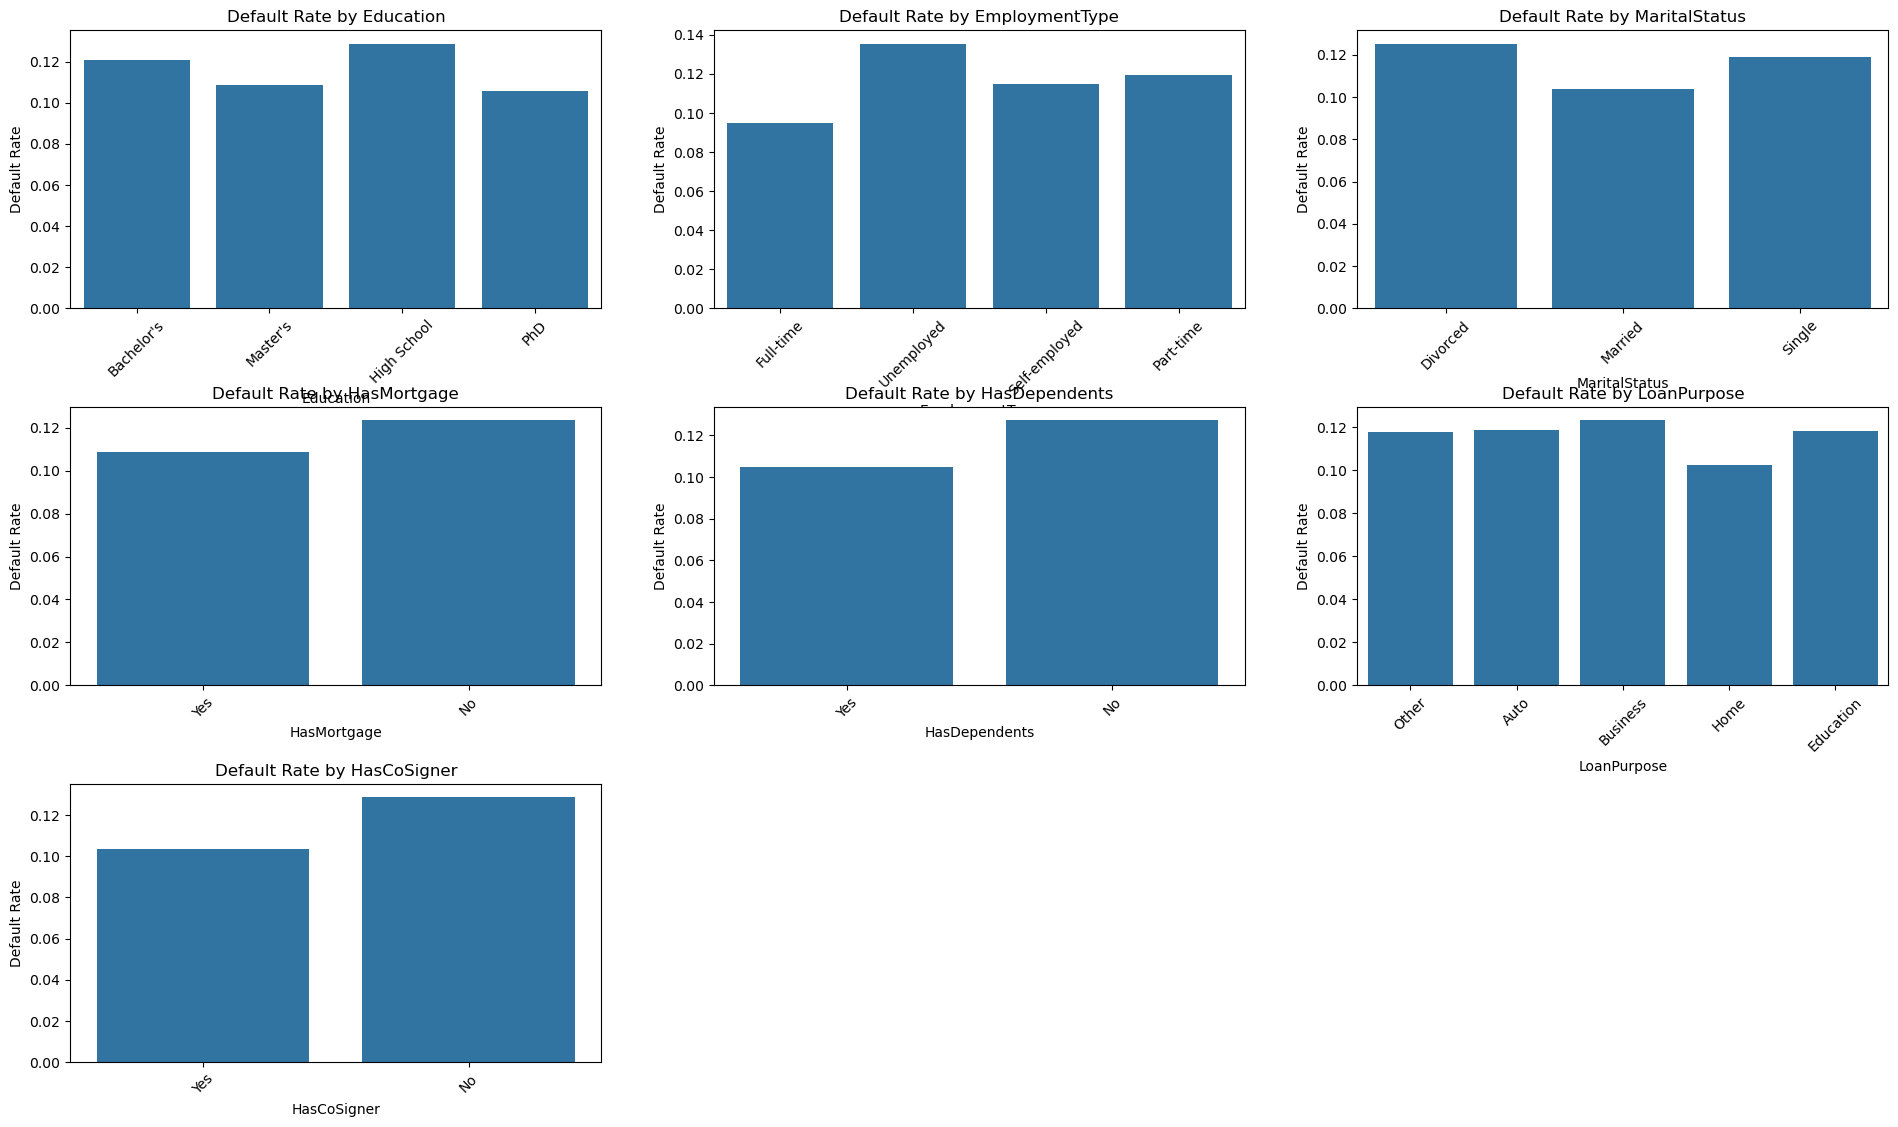

In [15]:
# Default Rate (Mean of staus) by Categorical Variables in a collage
# x = col → e.g. "Education", "EmploymentType", etc.
# y = 'Default' → this column in dataframe df contains binary values:
# 1 = loan defaulted
# 0 = loan not defaulted
categorical_columns = ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']
num_cols = 3  # Number of columns for the subplot grid
num_rows = (len(categorical_columns) + num_cols - 1) // num_cols  # Number of rows needed

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 12))
fig.tight_layout(pad=5.0)

for i, col in enumerate(categorical_columns):
    row = i // num_cols
    col_idx = i % num_cols
    sns.barplot(x=col, y='Default', data=df, errorbar=None, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'Default Rate by {col}')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Default Rate')
    axes[row, col_idx].tick_params(axis='x', rotation=45)

# Remove empty subplots
for i in range(len(categorical_columns), num_rows * num_cols):
    fig.delaxes(axes.flatten()[i])

plt.show()

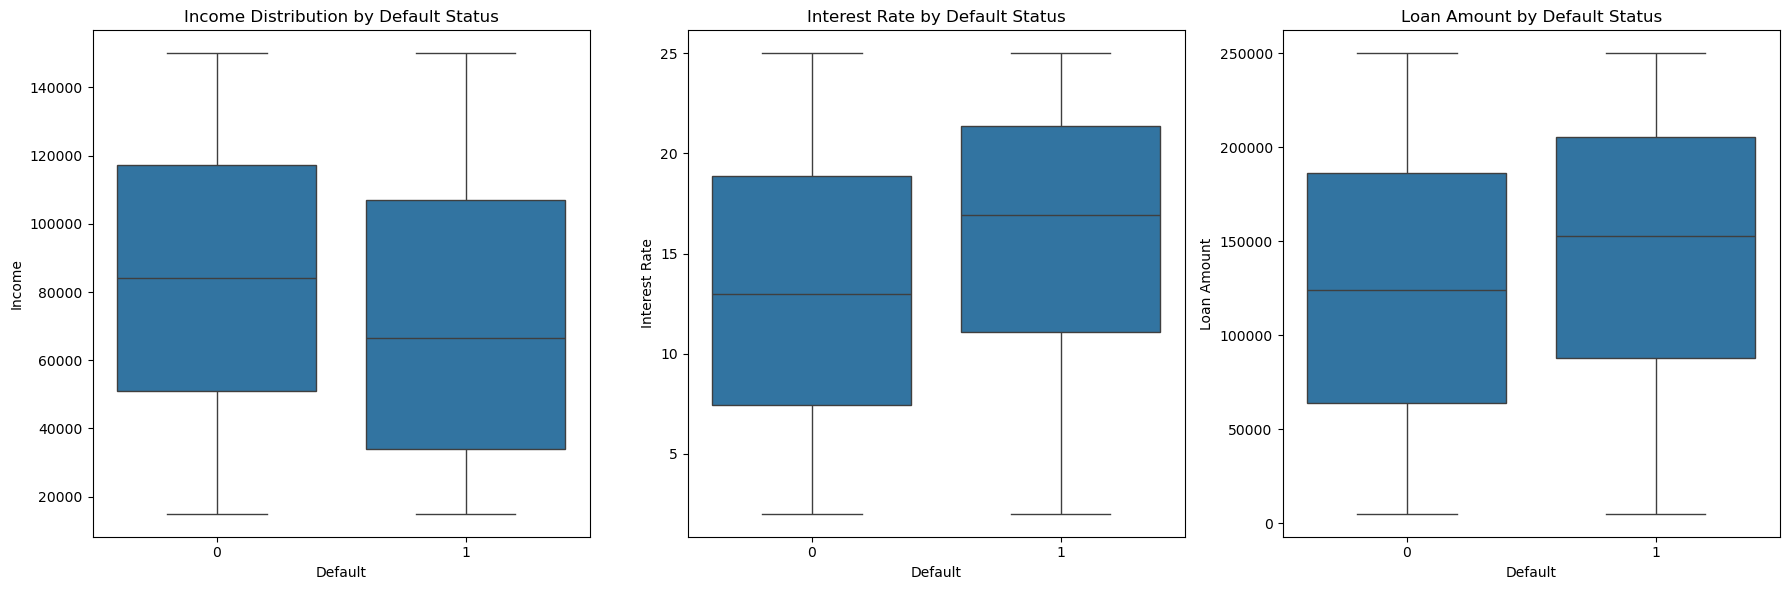

In [16]:
# Set up subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

# Income Distribution by Default Status
sns.boxplot(ax=axes[0], x='Default', y='Income', data=df)
axes[0].set_title('Income Distribution by Default Status')
axes[0].set_xlabel('Default')
axes[0].set_ylabel('Income')

# Interest Rate by Default Status
sns.boxplot(ax=axes[1], x='Default', y='InterestRate', data=df)
axes[1].set_title('Interest Rate by Default Status')
axes[1].set_xlabel('Default')
axes[1].set_ylabel('Interest Rate')

# Loan Amount by Default Status
sns.boxplot(ax=axes[2], x='Default', y='LoanAmount', data=df)
axes[2].set_title('Loan Amount by Default Status')
axes[2].set_xlabel('Default')
axes[2].set_ylabel('Loan Amount')

plt.tight_layout()
plt.show()


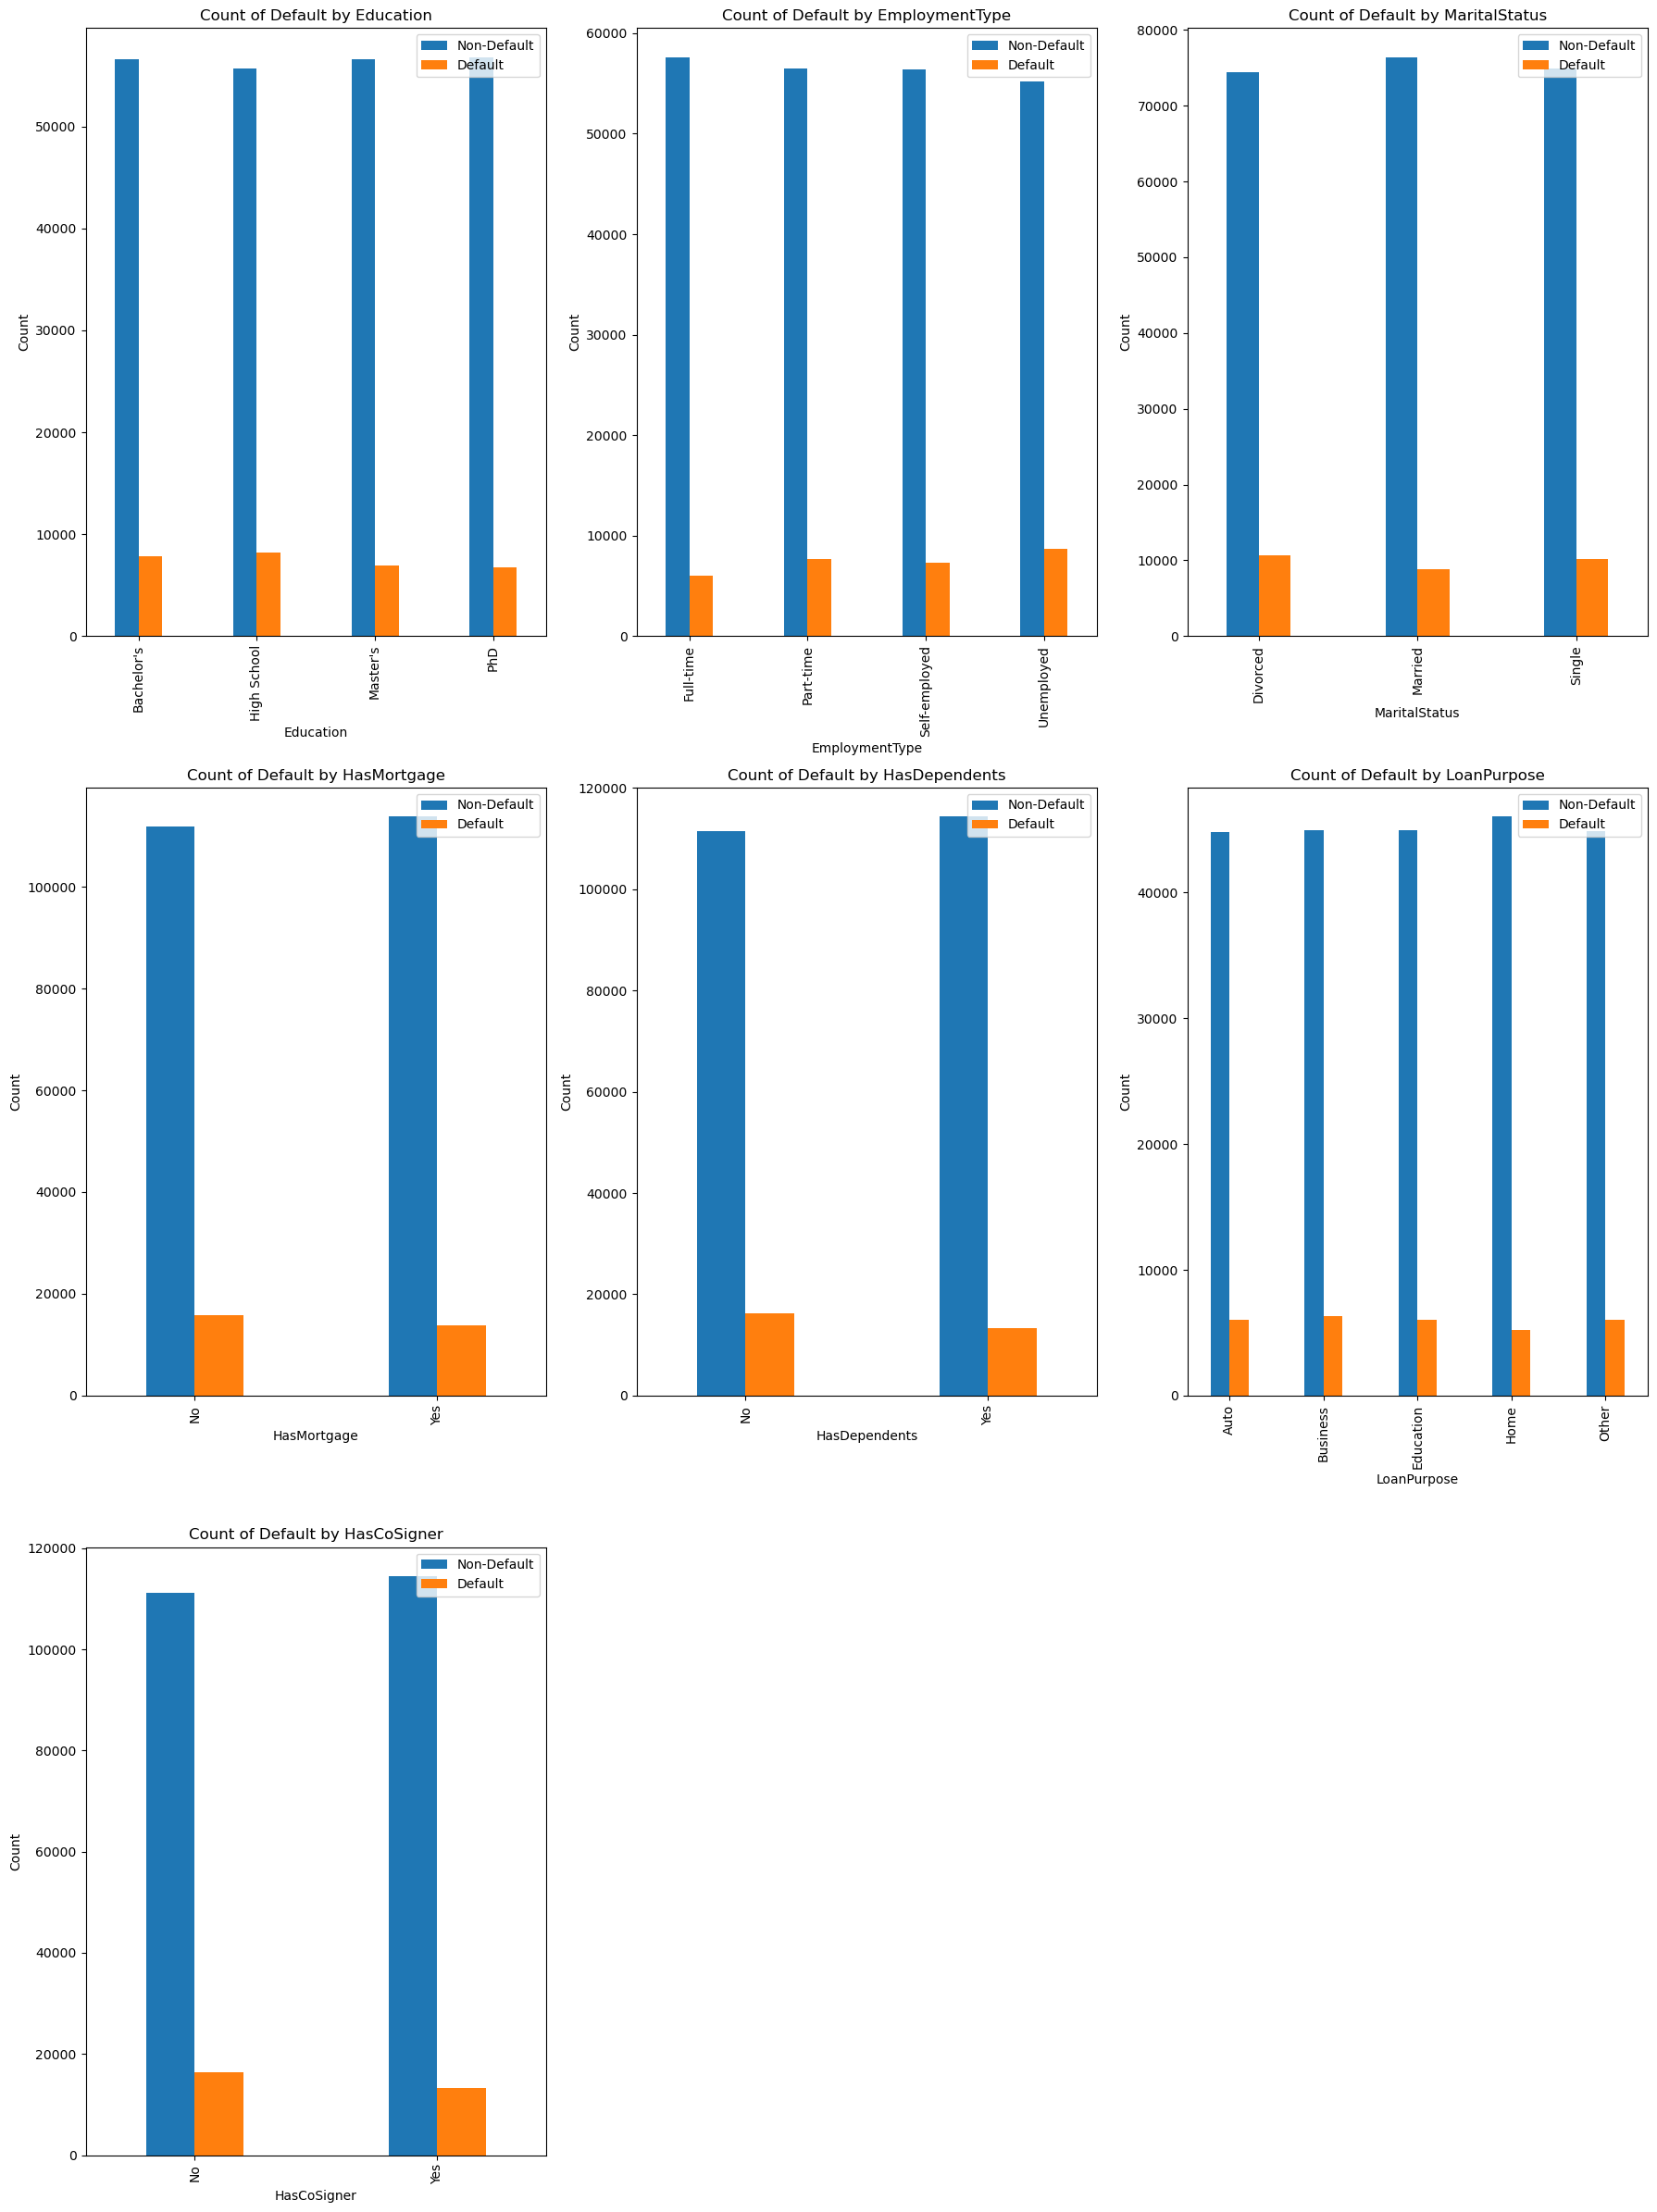

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define categorical columns
categorical_columns = ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

# Determine subplot layout
num_cols = 3  # Number of columns for the subplot grid
num_rows = (len(categorical_columns) + num_cols - 1) // num_cols  # Number of rows needed

# Create figure and axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 8 * num_rows))
fig.tight_layout(pad=5.0)

# Iterate through each categorical column and create bar plots
for i, col in enumerate(categorical_columns):
    row = i // num_cols
    col_idx = i % num_cols
    
    # Calculate counts of defaults and non-defaults for each category
    count_data = df.groupby([col, 'Default']).size().unstack()
    
    # Plot bar chart
    count_data.plot(kind='bar', ax=axes[row, col_idx], width=0.4)
    axes[row, col_idx].set_title(f'Count of Default by {col}')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Count')
    axes[row, col_idx].legend(['Non-Default', 'Default'], loc='upper right')

# Remove empty subplots if there are any
for i in range(len(categorical_columns), num_rows * num_cols):
    fig.delaxes(axes.flatten()[i])

plt.tight_layout()
plt.show()

In [18]:
df = df.drop(columns=['LoanID'])

In [19]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [20]:
from sklearn.preprocessing import LabelEncoder

# Define columns to be label encoded
cols_to_label_encode = ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Iterate over each column and apply label encoding
for col in cols_to_label_encode:
    df[col] = label_encoder.fit_transform(df[col])

In [21]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1,0
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1,0
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0,1
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,0,0,1,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0,0


In [22]:
#Define columns to one-hot encode
cols_to_one_hot_encode = ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

# Applying one-hot encoding using pandas
df = pd.get_dummies(df, columns=cols_to_one_hot_encode, drop_first=True)

In [23]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default,...,EmploymentType_3,MaritalStatus_1,MaritalStatus_2,HasMortgage_1,HasDependents_1,LoanPurpose_1,LoanPurpose_2,LoanPurpose_3,LoanPurpose_4,HasCoSigner_1
0,56,85994,50587,520,80,4,15.23,36,0.44,0,...,False,False,False,True,True,False,False,False,True,True
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,False,True,False,False,False,False,False,False,True,True
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,True,False,False,True,True,False,False,False,False,False
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,False,True,False,False,False,True,False,False,False,False
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,True,False,False,False,True,False,False,False,False,False


In [24]:
from sklearn.model_selection import train_test_split

In [25]:
# Assuming df is your DataFrame after encoding
X = df.drop(columns=['Default'])  # Features
y = df['Default']  # Target variable

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [26]:
# Print shapes to verify
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (178742, 24), y_train shape: (178742,)
X_test shape: (76605, 24), y_test shape: (76605,)


In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [29]:
# Print the first few rows of scaled data to verify
print("Scaled X_train:")
print(X_train_scaled[:5, :])  # Printing only the first 5 rows for brevity
print("\nScaled X_test:")
print(X_test_scaled[:5, :])   # Printing only the first 5 rows for brevity

Scaled X_train:
[[ 9.01776879e-01  5.19923714e-01 -6.07852662e-02 -1.64070647e+00
  -1.68880199e+00  4.45581754e-01  1.73360791e+00 -7.08163978e-01
   1.64369697e+00 -5.77914456e-01 -5.74210612e-01 -5.76493222e-01
  -5.79886968e-01  1.73517021e+00 -5.76562130e-01  1.41152378e+00
  -7.05036811e-01  1.00014547e+00  1.00034693e+00  1.99610608e+00
  -5.00704478e-01 -5.00127625e-01 -4.98947283e-01 -1.00058201e+00]
 [-1.65679213e-01  1.33991993e+00 -1.52538952e+00  1.66768659e+00
   7.19888236e-02 -1.34528168e+00  1.45941099e+00  1.41685106e+00
   1.60038637e+00  1.73035990e+00 -5.74210612e-01 -5.76493222e-01
  -5.79886968e-01 -5.76312337e-01  1.73441846e+00 -7.08454235e-01
  -7.05036811e-01 -9.99854550e-01  1.00034693e+00 -5.00975379e-01
  -5.00704478e-01 -5.00127625e-01 -4.98947283e-01  9.99418325e-01]
 [-1.43328332e+00 -1.84067522e-01  4.87188522e-01  1.46012581e+00
   5.62701018e-01  1.34101347e+00 -1.27351876e+00  1.74368012e-04
  -2.61969509e-01  1.73035990e+00 -5.74210612e-01 -5.76493

In [30]:
# Statistical method, Logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

In [31]:
logreg_model = LogisticRegression()

In [32]:
# Train the model
logreg_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [33]:
# Predict on test data
y_pred = logreg_model.predict(X_test_scaled)
y_pred_proba = logreg_model.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1

In [34]:
# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8850466679720644

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     67681
           1       0.62      0.03      0.07      8924

    accuracy                           0.89     76605
   macro avg       0.75      0.52      0.50     76605
weighted avg       0.86      0.89      0.84     76605



In [35]:
# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[67492   189]
 [ 8617   307]]


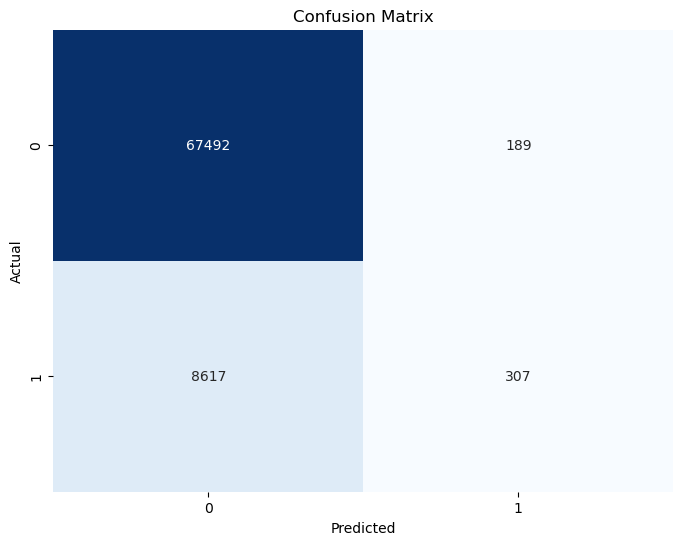

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', cbar=False)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [37]:
# ROC AUC
print("\nROC AUC Score:")
print(roc_auc_score(y_test, y_pred_proba))


ROC AUC Score:
0.7492025500543521


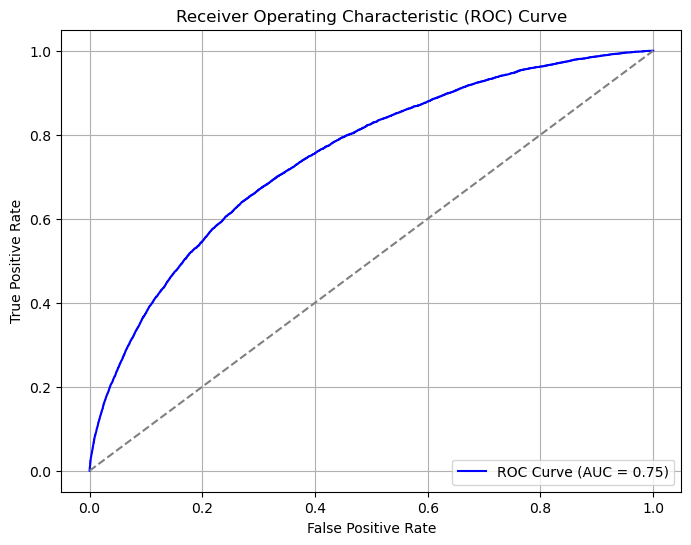

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')

plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [39]:
import joblib

In [40]:
# Save the model to a file
joblib.dump(logreg_model, 'logreg_model.pkl')
print("Model saved as logreg_model.pkl")

Model saved as logreg_model.pkl


In [41]:
## 2. K-NEAREST NEIGHBOURS

In [42]:
# Step 1: Import Required Libraries
from sklearn.neighbors import KNeighborsClassifier

In [43]:
# Step 2: Initialize the KNN Model
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can adjust the number of neighbors

In [44]:
# Step 3: Train the Model
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [45]:
# Step 4: Predict on Test Data
y_pred = knn_model.predict(X_test_scaled)
y_pred_proba = knn_model.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1

In [46]:
# Step 5: Evaluate the Model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8747079172377782

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93     67681
           1       0.29      0.05      0.09      8924

    accuracy                           0.87     76605
   macro avg       0.59      0.52      0.51     76605
weighted avg       0.82      0.87      0.83     76605



In [47]:
# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)


Confusion Matrix:
[[66556  1125]
 [ 8473   451]]


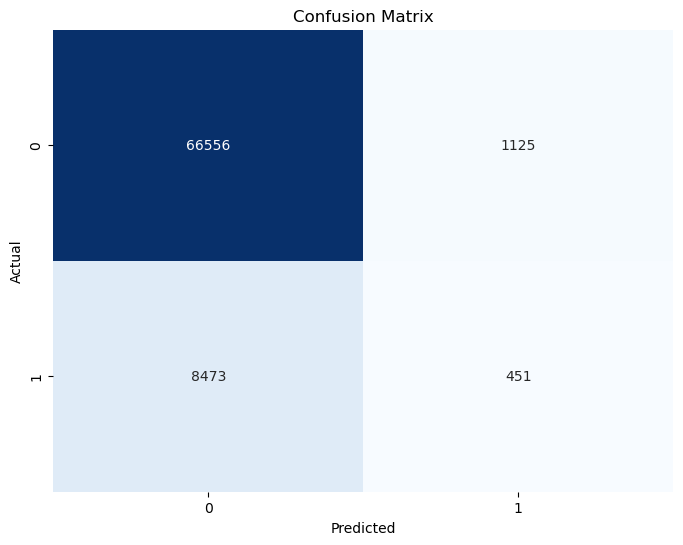

In [48]:
# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [49]:
# ROC AUC
print("\nROC AUC Score:")
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(roc_auc)


ROC AUC Score:
0.596261290449672


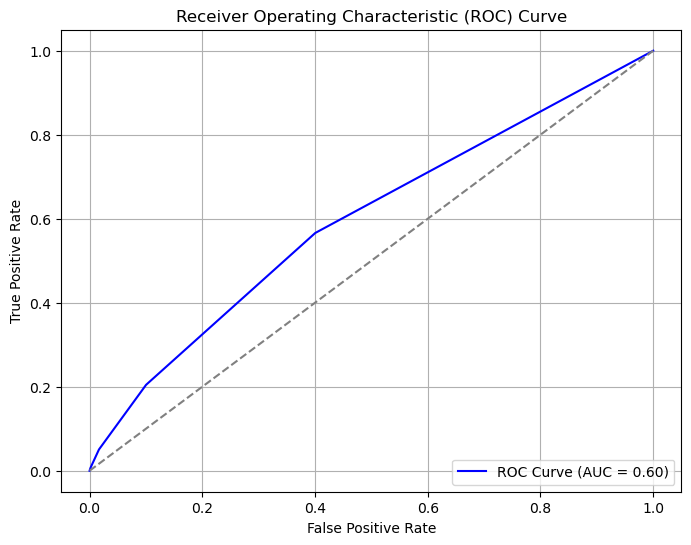

In [50]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [51]:
# Save the model to a file
joblib.dump(knn_model, 'knn_model.pkl')
print("Model saved as knn_model.pkl")

Model saved as knn_model.pkl


In [52]:
## 3. DECISION TREES

In [53]:
# Step 1: Import Required Libraries
from sklearn.tree import DecisionTreeClassifier

In [54]:
# Step 2: Initialize the Decision Tree Model
dt_model = DecisionTreeClassifier(random_state=42)

In [55]:
# Step 3: Train the Model
dt_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

In [56]:
#Step 4: Predict on Test Data
y_pred = dt_model.predict(X_test_scaled)
y_pred_proba = dt_model.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1

In [57]:
# Step 5: Evaluate the Model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8046472162391489

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     67681
           1       0.21      0.24      0.22      8924

    accuracy                           0.80     76605
   macro avg       0.55      0.56      0.55     76605
weighted avg       0.82      0.80      0.81     76605



In [58]:
# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)


Confusion Matrix:
[[59535  8146]
 [ 6819  2105]]


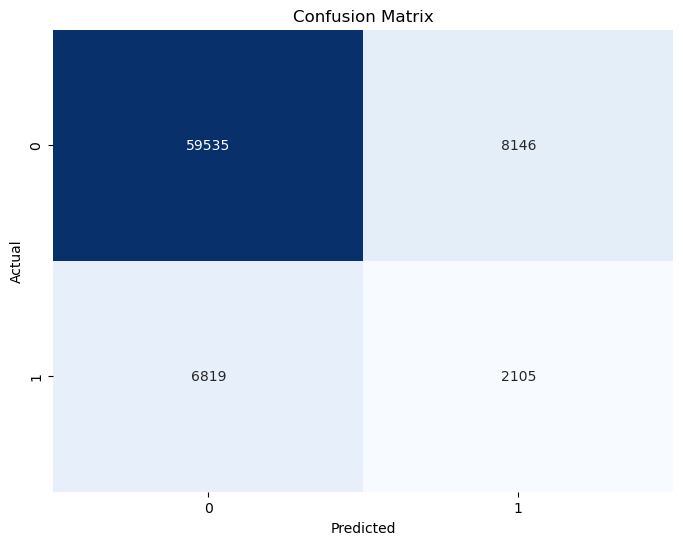

In [59]:
# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [60]:
# ROC AUC
print("\nROC AUC Score:")
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(roc_auc)


ROC AUC Score:
0.5577610146051846


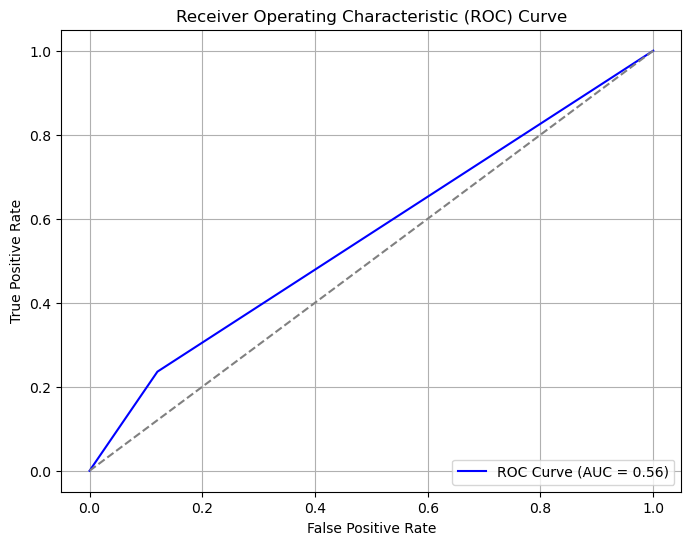

In [61]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [62]:
# Step 6: Save the Model
joblib.dump(dt_model, 'dt_model.pkl')
print("Model saved as dt_model.pkl")

Model saved as dt_model.pkl


In [63]:
## 4. NAIVES BAYES

In [64]:
# Step 1: Import Required Libraries
from sklearn.naive_bayes import GaussianNB

In [65]:
# Step 2: Initialize the Naive Bayes Model
nb_model = GaussianNB()

In [66]:
# Step 3: Train the Model
nb_model.fit(X_train_scaled, y_train)

GaussianNB()

In [67]:
# Step 4: Predict on Test Data
y_pred = nb_model.predict(X_test_scaled)
y_pred_proba = nb_model.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1

In [68]:
# Step 5: Evaluate the Model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8845767247568697

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     67681
           1       0.61      0.02      0.05      8924

    accuracy                           0.88     76605
   macro avg       0.75      0.51      0.49     76605
weighted avg       0.85      0.88      0.83     76605



In [69]:
# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)


Confusion Matrix:
[[67541   140]
 [ 8702   222]]


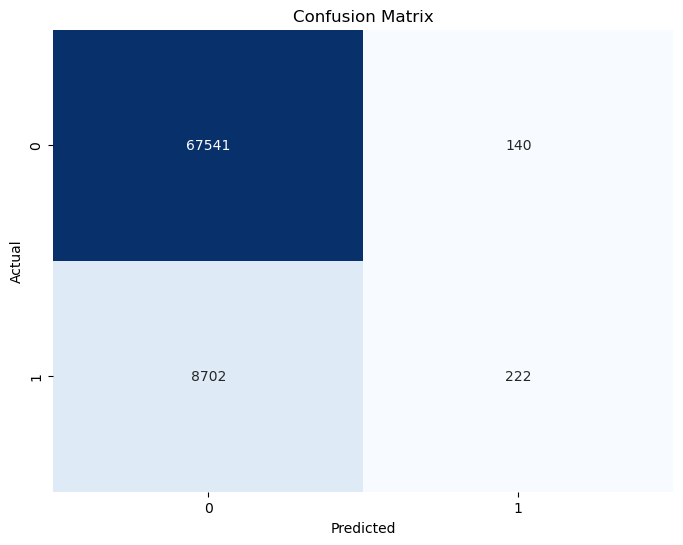

In [70]:
# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [71]:
# ROC AUC
print("\nROC AUC Score:")
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(roc_auc)


ROC AUC Score:
0.7459465267995852


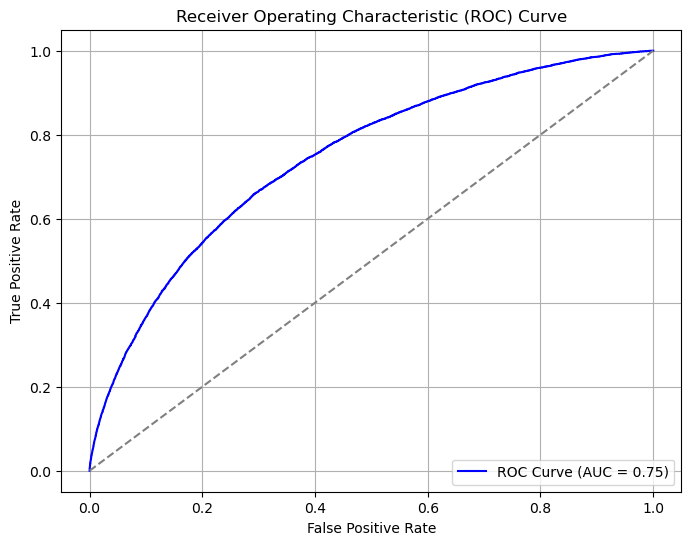

In [72]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [73]:
# Step 6: Save the Model
joblib.dump(nb_model, 'nb_model.pkl')
print("Model saved as nb_model.pkl")

Model saved as nb_model.pkl


In [74]:
## 5. RANDOM FOREST

In [75]:
#Step 1: Import Required Libraries
from sklearn.ensemble import RandomForestClassifier

In [76]:
# Step 2: Initialize the Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [77]:
# Step 3: Train the Model
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [78]:
# Step 4: Predict on Test Data
y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1

In [79]:
# Step 5: Evaluate the Model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8852946935578617

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     67681
           1       0.67      0.03      0.06      8924

    accuracy                           0.89     76605
   macro avg       0.78      0.51      0.50     76605
weighted avg       0.86      0.89      0.84     76605



In [80]:
# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)


Confusion Matrix:
[[67549   132]
 [ 8655   269]]


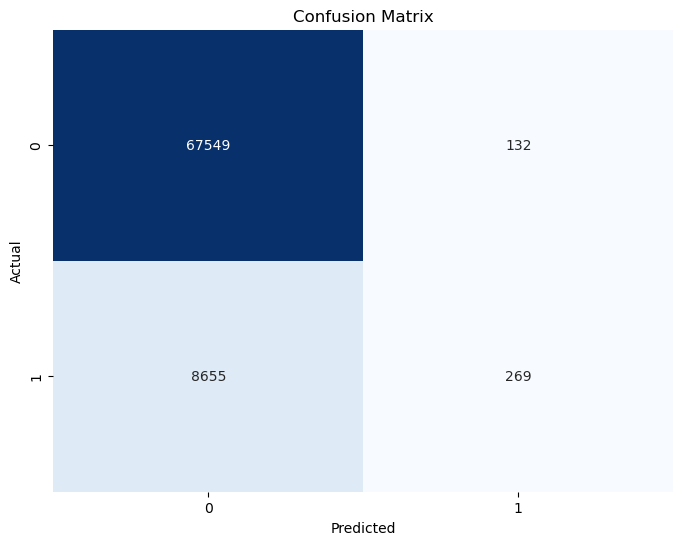

In [81]:
# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [82]:
# ROC AUC
print("\nROC AUC Score:")
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(roc_auc)


ROC AUC Score:
0.7310156678264809


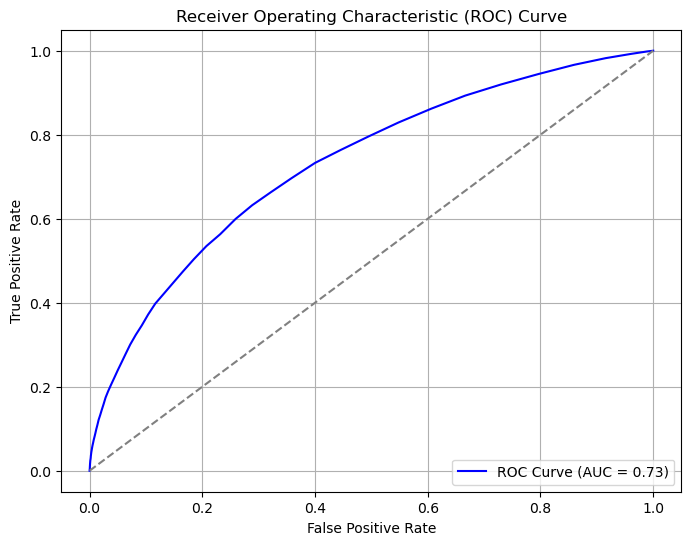

In [83]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [84]:
# Step 6: Save the Model
joblib.dump(rf_model, 'rf_model.pkl')
print("Model saved as rf_model.pkl")


Model saved as rf_model.pkl


In [85]:
## 6. LINEAR DISCRIMINANT ANALYSIS (LDA)

In [86]:
# Step 1: Import Required Libraries
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [87]:
# Step 2: Initialize the LDA Model
lda_model = LinearDiscriminantAnalysis()

In [88]:
# Step 3: Train the Model
lda_model.fit(X_train_scaled, y_train)

LinearDiscriminantAnalysis()

In [89]:
# Step 4: Predict on Test Data
y_pred = lda_model.predict(X_test_scaled)
y_pred_proba = lda_model.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1

In [90]:
# Step 5: Evaluate the Model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8849291821682658

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     67681
           1       0.63      0.03      0.06      8924

    accuracy                           0.88     76605
   macro avg       0.76      0.51      0.50     76605
weighted avg       0.86      0.88      0.84     76605



In [91]:
# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)


Confusion Matrix:
[[67529   152]
 [ 8663   261]]


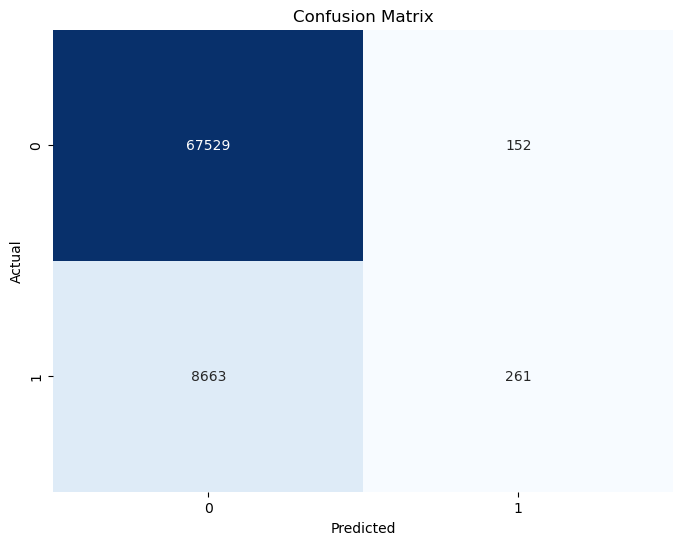

In [92]:
# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [93]:
# ROC AUC
print("\nROC AUC Score:")
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(roc_auc)


ROC AUC Score:
0.7491879950630053


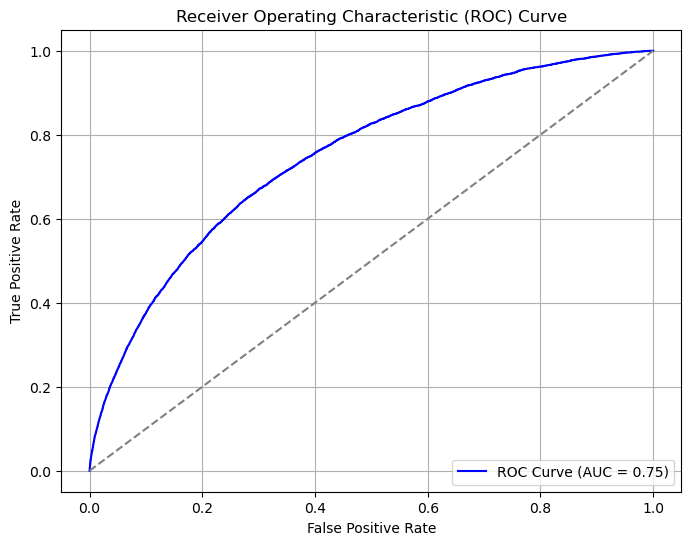

In [94]:

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [95]:
# Step 6: Save the Model
joblib.dump(lda_model, 'lda_model.pkl')
print("Model saved as 'lda_model.pkl")

Model saved as 'lda_model.pkl
